<a href="https://colab.research.google.com/github/AjithVargheseTH/NASA-Space-Apps-Challenge-TEAM-Astrohacks/blob/main/ChatBotPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EMOTION AWARE CHATBOT**


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/NLP_Project/go_emotions_dataset.csv')
df.head()


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.columns

Index(['id', 'text', 'example_very_unclear', 'admiration', 'amusement',
       'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
       'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral'],
      dtype='object')

In [ ]:

emotion_columns = df.columns[3:]

def get_primary_emotion(row):
    for emotion in emotion_columns:
        if row[emotion] == 1:
            return emotion
    return 'neutral'

df['primary_emotion'] = df.apply(get_primary_emotion, axis=1)

df_filtered = df[['text', 'primary_emotion']].copy()

df_filtered.head()

,text,primary_emotion
0,That game hurt.,sadness
1,>sexuality shouldn’t be a grouping category I...,neutral
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral


/tmp/ipython-input-4-2162737813.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="Spectral")


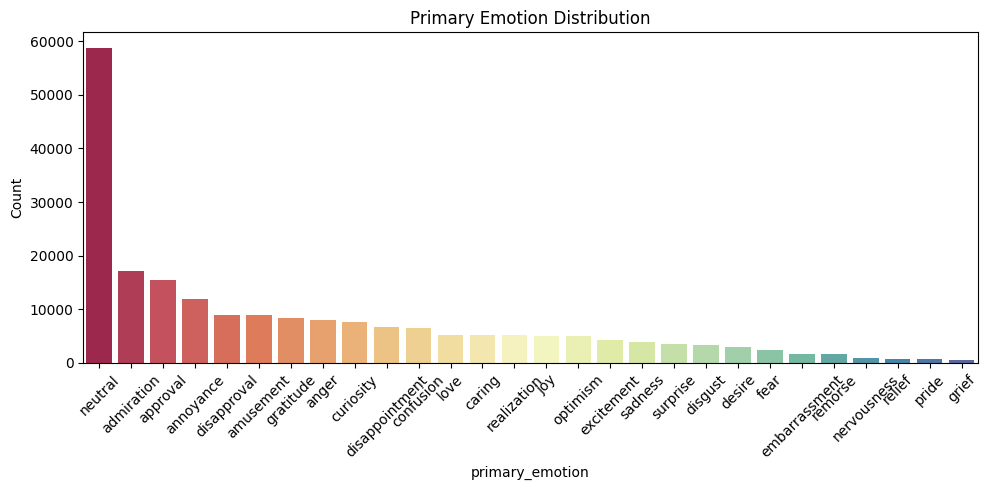

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

emotion_counts = df_filtered['primary_emotion'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="Spectral")
plt.title("Primary Emotion Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
!pip install transformers


In [ ]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=False
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
def detect_emotion(text):
    result = emotion_classifier(text)
    return result[0]['label']



In [ ]:
!pip install transformers accelerate

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "deepseek-ai/deepseek-llm-7b-chat"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto", # automatically uses fp16 if supported
    device_map="auto"   # puts the model on GPU
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def generate_deepseek_response(user_message, detected_emotion):
    prompt = (
        f"<|system|>\n"
        f"You are a helpful, empathetic study assistant.\n"
        f"The user feels {detected_emotion}.\n"
        f"</s>\n"
        f"<|user|>\n"
        f"{user_message}\n"
        f"</s>\n"
        f"<|assistant|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    output = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=True,
        top_p=0.9,
        temperature=0.7
    )

    response = tokenizer.decode(output[0], skip_special_tokens=True)
    # Remove prompt from output
    response = response.split("<|assistant|>")[-1].strip()
    return response


In [ ]:
print(generate_deepseek_response("I feel like giving up on this course.", "sadness"))

Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.


I'm sorry to hear that you're feeling that way. It's understandable to feel overwhelmed or discouraged when faced with challenges in academic work or personal life. However, it's important to remember that you have the power to overcome these obstacles and achieve your goals.

Here are a few tips that might help:

1. Break tasks into smaller steps: When you feel overwhelmed by a large assignment or project, try breaking it down into smaller, more manageable tasks. This will help you feel more in control and make the task seem less daunting.
2. Prioritize your tasks: Identify which tasks are most important or urgent and focus on those first. This will help you stay organized and prevent you from feeling like you


In [ ]:
def chatbot_response(user_input):
    emotion = detect_emotion(user_input)
    response = generate_deepseek_response(user_input, emotion)
    return response

In [ ]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit']:
        print("Bot: Bye! You got this 💪")
        break
    response = chatbot_response(user_input)
    print("Bot:", response)#, f"(Emotion: {detect_emotion(user_input)})")



You: Hey


Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.


Bot: Hello! How can I assist you today?
You: Man learning about gravity is so tough?


Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.


Bot: Learning about gravity can be challenging, but with the right resources and approach, it can be enjoyable and rewarding. There are many resources available to help users understand gravity, such as books, articles, videos, and interactive simulations.

Some popular books on gravity include "Gravity" by Michio Kaku and "The Science of Star Trek" by Kip S. Thorne. These books provide a comprehensive overview of gravity and its applications in science fiction.

There are also many articles and videos online that can help users learn about gravity. For example, the National Geographic website has an article on gravity that provides an overview of the subject, while NASA's website has a section on gravity that includes interactive simulations and videos.

Overall,
You: exit
Bot: Bye! You got this 💪


In [ ]:

df_eval = df_filtered.sample(500, random_state=42).copy()
df_eval['detected_emotion'] = df_eval['text'].apply(detect_emotion)


In [ ]:
 from sklearn.metrics import classification_report

y_true = df_eval['primary_emotion']
y_pred = df_eval['detected_emotion']


print(classification_report(y_true, y_pred))


                precision    recall  f1-score   support

    admiration       0.00      0.00      0.00        42
     amusement       0.00      0.00      0.00        18
         anger       0.29      0.57      0.38        23
     annoyance       0.00      0.00      0.00        30
      approval       0.00      0.00      0.00        50
        caring       0.00      0.00      0.00        11
     confusion       0.00      0.00      0.00        11
     curiosity       0.00      0.00      0.00        20
        desire       0.00      0.00      0.00         8
disappointment       0.00      0.00      0.00        14
   disapproval       0.00      0.00      0.00        19
       disgust       0.03      0.50      0.06         4
 embarrassment       0.00      0.00      0.00         5
    excitement       0.00      0.00      0.00         9
          fear       0.17      1.00      0.29         3
     gratitude       0.00      0.00      0.00        16
         grief       0.00      0.00      0.00  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


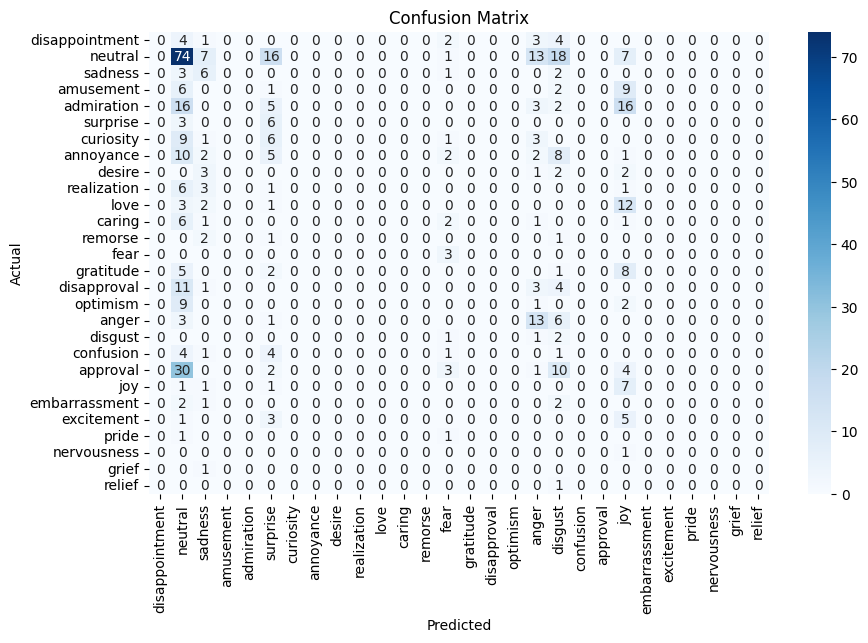

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=y_true.unique())

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=y_true.unique(), yticklabels=y_true.unique(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True
)


Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


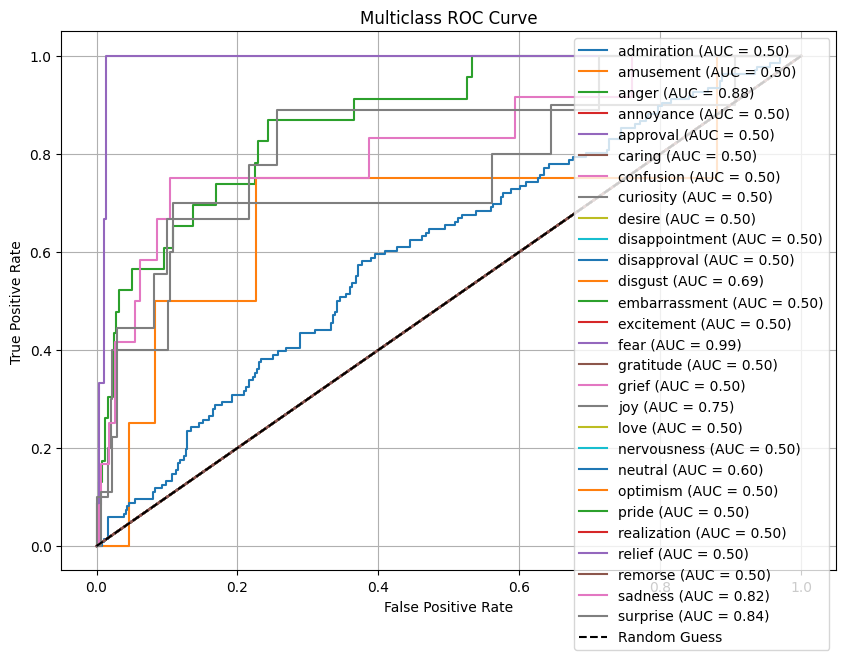

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Use the same subset
texts = df_eval['text'].tolist()
true_labels = df_eval['primary_emotion'].tolist()
classes = sorted(df_eval['primary_emotion'].unique())

# Binarize labels
y_test = label_binarize(true_labels, classes=classes)
n_classes = y_test.shape[1]

# Get predicted probabilities for each class
y_score = []
for text in texts:
    preds = emotion_classifier(text)[0]  # get list of dicts
    scores = {p['label']: p['score'] for p in preds}
    y_score.append([scores.get(cls, 0) for cls in classes])

y_score = np.array(y_score)

# Plot ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend()
plt.grid()
plt.show()
